# Quantum gases: Free Fermi gas

This notebook is part of the computational resources for the Statistical Physics course at École Polytechnique. To return to the main repository, follow this link: [https://github.com/cossio/StatPhysCompX](https://github.com/cossio/StatPhysCompX).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants, optimize

In [2]:
# Physical constants (SI units)
hbar = constants.hbar           # Reduced Planck constant (J·s)
kB = constants.Boltzmann        # Boltzmann constant (J/K)
eV = constants.eV               # 1 eV in Joules
m_e = constants.electron_mass   # Electron mass (kg)

# Target number density (electrons in Cu)
rho = 8.47e28  # m^{-3}

In [3]:
def energy(k):
    """Free-particle energy spectrum."""
    return (hbar * k)**2 / (2 * m_e)

def fermi(eps, mu, T):
    """Fermi-Dirac distribution."""
    x = (eps - mu) / (kB * T)
    return 1 / (np.exp(x) + 1)

def state_density(E):
    """
    Density of states for a free, non-relativistic particle of mass m_e in 3D.
    Returns the number of states per unit energy per unit volume.
    Factor of 2 accounts for spin degeneracy.
    """
    return 2 * (2 * m_e)**(3/2) / (2 * np.pi**2 * hbar**3) * np.sqrt(E)

## Fermi-Dirac distribution

The Fermi-Dirac distribution gives the average occupation number of a single-particle state with energy $\epsilon$:

$$n(\epsilon) = \frac{1}{e^{(\epsilon - \mu)/k_B T} + 1}$$

/tmp/ipykernel_1440569/655041361.py:8: RuntimeWarning: overflow encountered in exp
  return 1 / (np.exp(x) + 1)


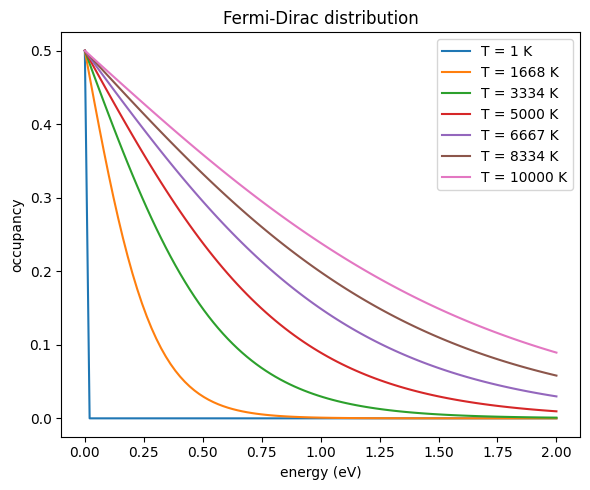

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
eps = np.linspace(0, 2, 100) * eV
temperatures = np.round(np.linspace(1, 10000, 7))
for T in temperatures:
    ax.plot(eps / eV, fermi(eps, 0, T), label=f"T = {T:.0f} K")
ax.set_xlabel("energy (eV)")
ax.set_ylabel("occupancy")
ax.set_title("Fermi-Dirac distribution")
ax.legend()
plt.tight_layout()
plt.show()

## Density of states

For a free, non-relativistic particle of mass $m$ in three dimensions, the density of states (number of single-particle eigenstates per unit energy per unit volume, including a factor of 2 for spin) is:

$$g(E) = \frac{2 (2m)^{3/2}}{2\pi^2 \hbar^3} \sqrt{E}$$

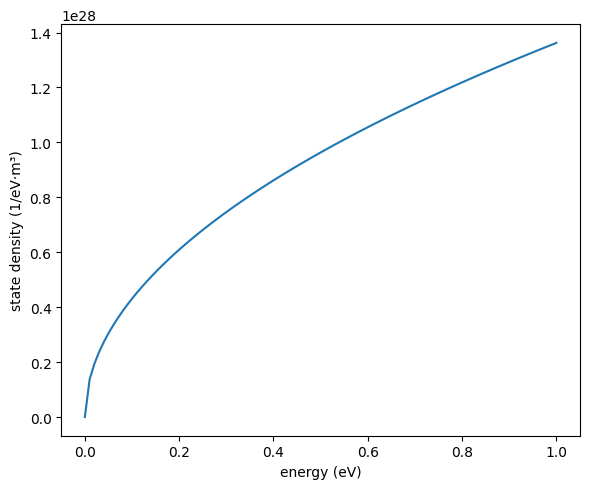

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
eps = np.linspace(0, 1, 100) * eV
ax.plot(eps / eV, state_density(eps) * eV)
ax.set_xlabel("energy (eV)")
ax.set_ylabel("state density (1/eV·m³)")
plt.tight_layout()
plt.show()

## Particle number density

The particle number density is obtained by integrating the product of the density of states and the Fermi-Dirac distribution:

$$n(\mu, T) = \int_0^\infty g(E) \, f(E, \mu, T) \, dE$$

In [7]:
def particle_number(mu, T):
    """Compute particle number density by numerical integration."""
    E = np.linspace(0, 20 * eV, 8000)
    integrand = state_density(E) * fermi(E, mu, T)
    return np.trapezoid(integrand, E)

/tmp/ipykernel_1440569/655041361.py:8: RuntimeWarning: overflow encountered in exp
  return 1 / (np.exp(x) + 1)


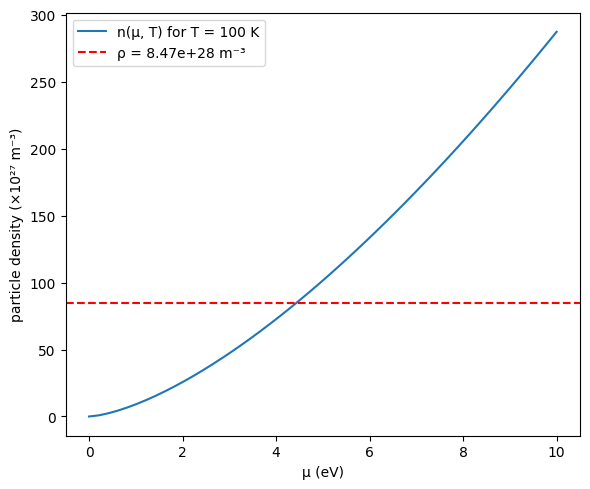

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
mu_vals = np.linspace(0, 10, 50) * eV
n_vals = [particle_number(mu, 100) for mu in mu_vals]
ax.plot(mu_vals / eV, np.array(n_vals) * 1e-27, label="n(μ, T) for T = 100 K")
ax.axhline(rho * 1e-27, linestyle="--", color="red", label=f"ρ = {rho:.2e} m⁻³")
ax.set_xlabel("μ (eV)")
ax.set_ylabel("particle density (×10²⁷ m⁻³)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Chemical potential

The chemical potential $\mu(T)$ is determined by the condition $n(\mu, T) = \rho$. We solve this equation numerically for $\mu$.

In [10]:
def chemical_potential_free_fermi(T, rho):
    """Solve n(mu, T) = rho for mu."""
    f = lambda mu: particle_number(mu, T) - rho
    sol = optimize.brentq(f, 0, 20 * eV)
    return sol

/tmp/ipykernel_1440569/655041361.py:8: RuntimeWarning: overflow encountered in exp
  return 1 / (np.exp(x) + 1)


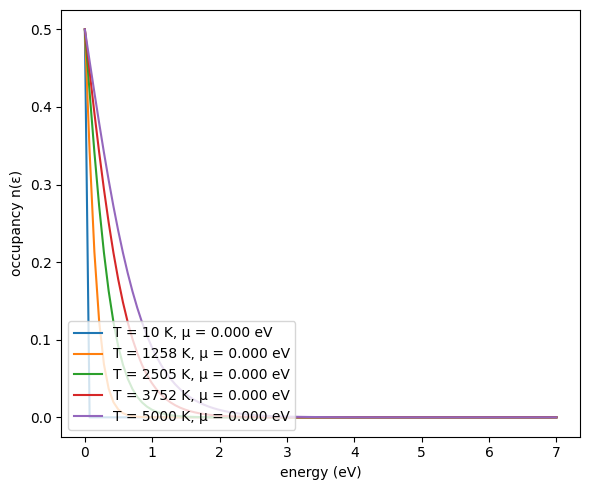

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
eps = np.linspace(0, 7, 100) * eV
temperatures = np.linspace(10, 5000, 5)
for T in temperatures:
    mu = chemical_potential_free_fermi(T, rho)
    ax.plot(eps / eV, fermi(eps, mu, T),
            label=f"T = {T:.0f} K, μ = {mu/eV:.3f} eV")
ax.set_xlabel("energy (eV)")
ax.set_ylabel("occupancy n(ε)")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()